- This notebook, we learn about how Overfitting is reduced using Regularization while training the Artificial Neural Network

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow
import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

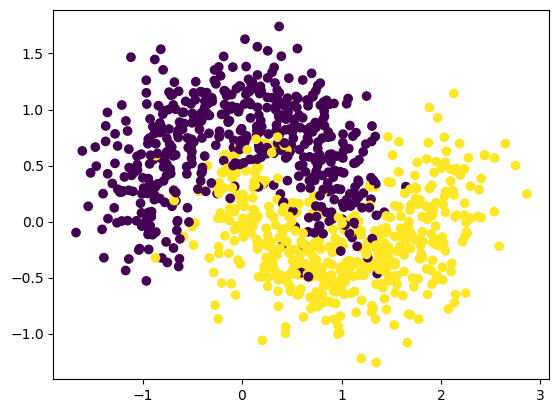

In [24]:
X,y = make_moons(n_samples=1000 , noise=0.3 , random_state=42)
plt.scatter(X[:,0],X[:,1] , c=y,cmap='viridis')
plt.show()

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(800, 2)
(800,)
(200, 2)
(200,)


### Without Regularization

In [26]:
# Let us build the ANN 
model = Sequential()
model.add(Dense(128 , activation='relu', input_dim=2))
model.add(Dense(128 , activation='relu'))
model.add(Dense(1 , activation='sigmoid'))
# model.summary()
from tensorflow.keras.optimizers import Adam
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy',optimizer=adam , metrics=['accuracy'])
history = model.fit(X_train,y_train , validation_data=(X_test,y_test) , epochs=1000 , verbose=0)

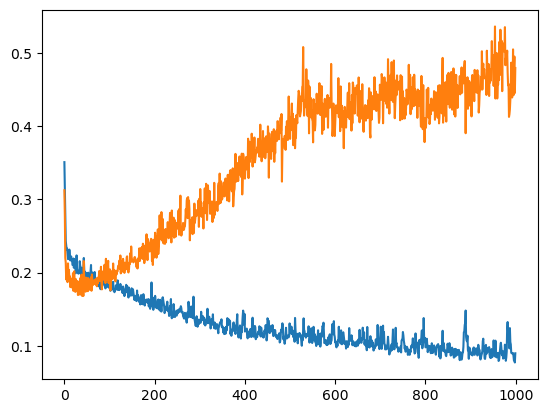

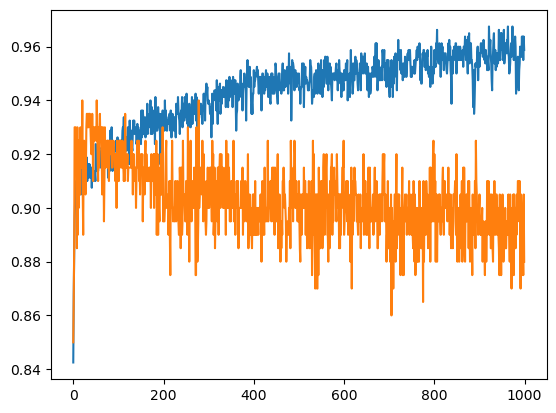

In [27]:
# Let us plot the curves
plt.plot(history.history['loss'] , label='train_loss')
plt.plot(history.history['val_loss'] , label='test_loss')
plt.show()
plt.plot(history.history['accuracy'] , label='train_acc')
plt.plot(history.history['val_accuracy'] , label='test_acc')
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 622us/step


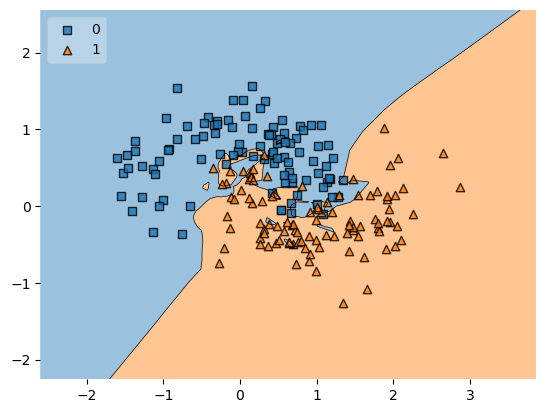

In [28]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_test,y_test, clf=model , legend=2)
plt.show()

- This is a clear case of over fitting

### Using Regularization

In [29]:
# Let us build the ANN 
model2 = Sequential()
model2.add(Dense(128 , activation='relu', input_dim=2 , kernel_regularizer=tensorflow.keras.regularizers.l2(0.02)))
model2.add(Dense(128 , activation='relu', kernel_regularizer=tensorflow.keras.regularizers.l2(0.02)))
model2.add(Dense(1 , activation='sigmoid'))
# model.summary()
from tensorflow.keras.optimizers import Adam
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy',optimizer=adam , metrics=['accuracy'])
history2 = model2.fit(X_train,y_train , validation_data=(X_test,y_test) , epochs=1000 , verbose=0)

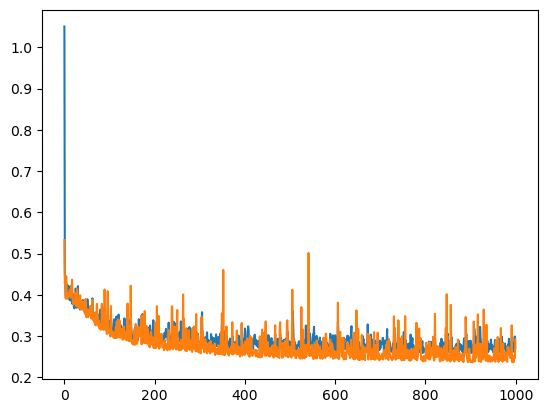

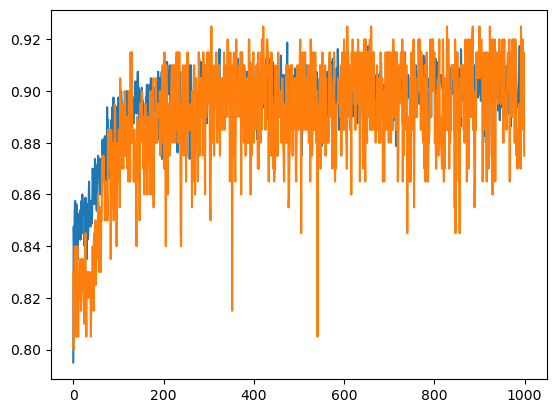

In [30]:
# Let us plot the curves
plt.plot(history2.history['loss'] , label='train_loss')
plt.plot(history2.history['val_loss'] , label='test_loss')
plt.show()
plt.plot(history2.history['accuracy'] , label='train_acc')
plt.plot(history2.history['val_accuracy'] , label='test_acc')
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 605us/step


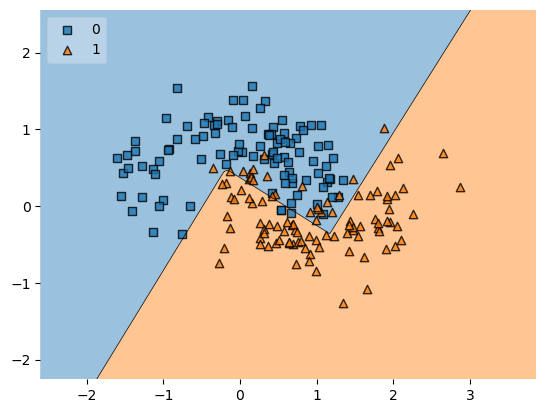

In [31]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_test,y_test, clf=model2 , legend=2)
plt.show()

- See that the model is now actually predicting good, the overfitting is almost gone.